# Iris Flower Classification

## Oasis Infobyte Data Science Internship — Task 1

### Objective

Build a machine learning classification model to classify iris flowers
into their respective species based on their physical measur

## Project Workflow

1. Load the Iris dataset
2. Create and inspect the dataset
3. Perform Exploratory Data Analysis (EDA)
4. Visualize feature distributions by species
5. Identify the most discriminative features
6. Split the data into training and testing sets
7. Train Logistic Regression and KNN classifiers
8. Evaluate both models
9. Compare model performance
10. Select the best-performing model
11. Predict the species of a new flower
12. Summarize the findingsements.

### Species

- Setosa
- Versicolor
- Virginica

### Technologies Used

- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn
- Jupyter Notebook

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

In [3]:
# Load the built-in Iris dataset from scikit-learn
iris = load_iris()

In [4]:
print("Feature names:")
print(iris.feature_names)

print("\nTarget names:")
print(iris.target_names)

print("\nDataset shape:")
print(iris.data.shape)

Feature names:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names:
['setosa' 'versicolor' 'virginica']

Dataset shape:
(150, 4)


In [5]:
# Create a pandas DataFrame using the Iris feature names
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target species to the DataFrame
df["species"] = iris.target

In [6]:
df["species"] = df["species"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(150, 5)


In [8]:
print("Data Types:")
print(df.dtypes)

Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object


In [9]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [10]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [11]:
print("Number of flowers in each species:")
print(df["species"].value_counts())

Number of flowers in each species:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


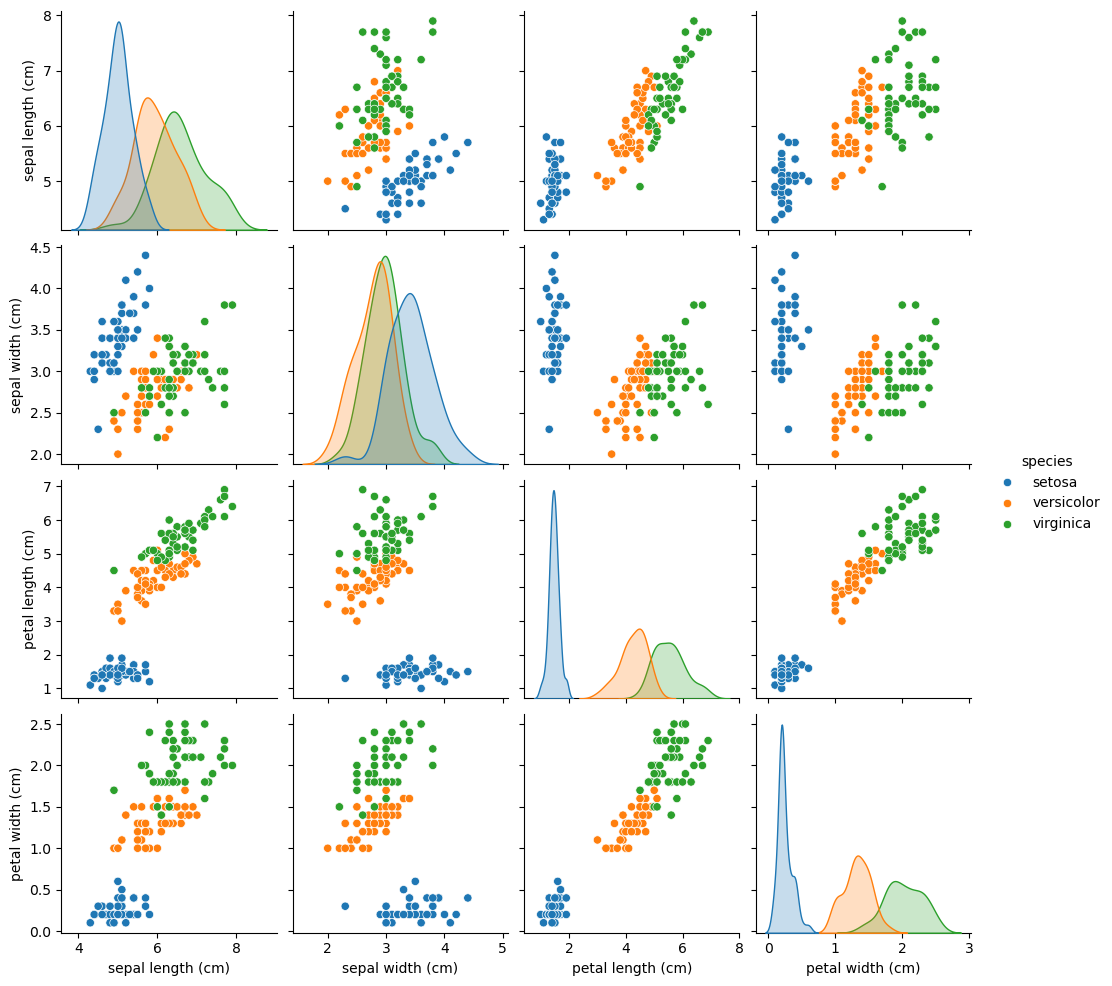

In [12]:
sns.pairplot(df, hue="species")

plt.show()

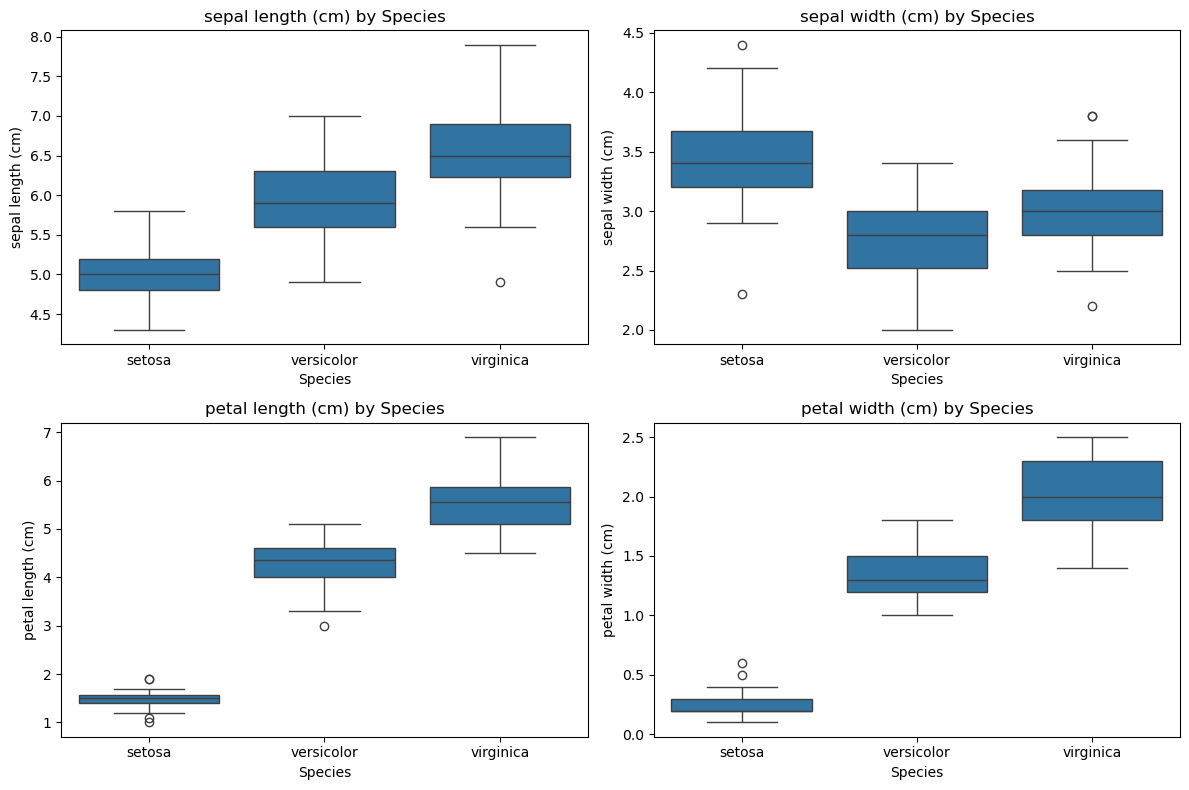

In [13]:
plt.figure(figsize=(12, 8))

for i, feature in enumerate(iris.feature_names, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x="species", y=feature)
    plt.title(f"{feature} by Species")
    plt.xlabel("Species")
    plt.ylabel(feature)

plt.tight_layout()
plt.show()

## EDA Findings

- The dataset contains 150 observations and 5 columns.
- There are 4 numerical features and 1 categorical target variable.
- The dataset contains no missing values.
- Each species contains 50 observations, so the classes are balanced.
- Petal length and petal width show the clearest separation between the three species.
- Sepal length also provides useful information for distinguishing the species.
- Sepal width shows comparatively more overlap between the species.
- The box plots show a few potential outliers, but they are retained because they may represent valid observations.

In [15]:
X = df[iris.feature_names]
y = df["species"]

In [16]:
print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Target (y):
0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object


In [17]:
from sklearn.model_selection import train_test_split

In [18]:
# Split the dataset into 80% training data and 20% testing data
# stratify=y keeps the three species equally represented in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [19]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (120, 4)
Testing features: (30, 4)
Training target: (120,)
Testing target: (30,)


In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
# Create and train the Logistic Regression classifier
logistic_model = LogisticRegression(max_iter=200)
logistic_model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [22]:
logistic_model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [23]:
y_pred_logistic = logistic_model.predict(X_test)

In [24]:
print(y_pred_logistic)

['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor' 'virginica'
 'virginica' 'virginica' 'versicolor' 'setosa' 'virginica' 'setosa']


In [25]:
from sklearn.metrics import accuracy_score

In [26]:
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.9666666666666667


In [27]:
print(f"Logistic Regression Accuracy: {logistic_accuracy * 100:.2f}%")

Logistic Regression Accuracy: 96.67%


In [28]:
from sklearn.metrics import confusion_matrix

In [29]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

print("Confusion Matrix:")
print(cm_logistic)

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


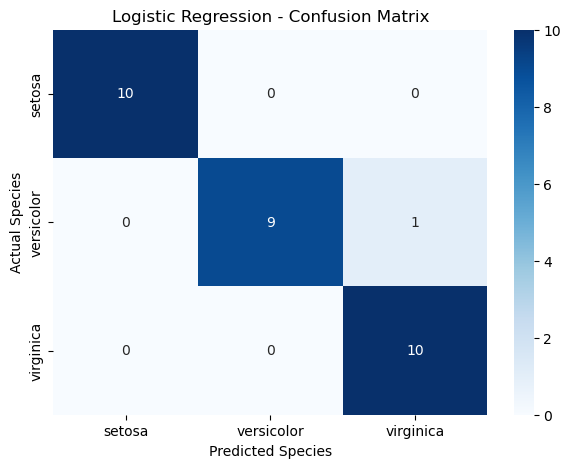

In [30]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

plt.show()

In [31]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test, y_pred_logistic))

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [32]:
from sklearn.neighbors import KNeighborsClassifier

In [33]:
# Create and train the KNN classifier using 5 nearest neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [34]:
knn_model.fit(X_train, y_train)

KNeighborsClassifier()

In [35]:
y_pred_knn = knn_model.predict(X_test)

In [36]:
print("KNN Predictions:")
print(y_pred_knn)

KNN Predictions:
['setosa' 'virginica' 'versicolor' 'versicolor' 'setosa' 'versicolor'
 'setosa' 'setosa' 'virginica' 'versicolor' 'virginica' 'virginica'
 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'versicolor' 'virginica'
 'virginica' 'versicolor' 'versicolor' 'setosa' 'virginica' 'setosa']


In [37]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)
print(f"KNN Accuracy: {knn_accuracy * 100:.2f}%")

KNN Accuracy: 1.0
KNN Accuracy: 100.00%


In [38]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

print("KNN Confusion Matrix:")
print(cm_knn)

KNN Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


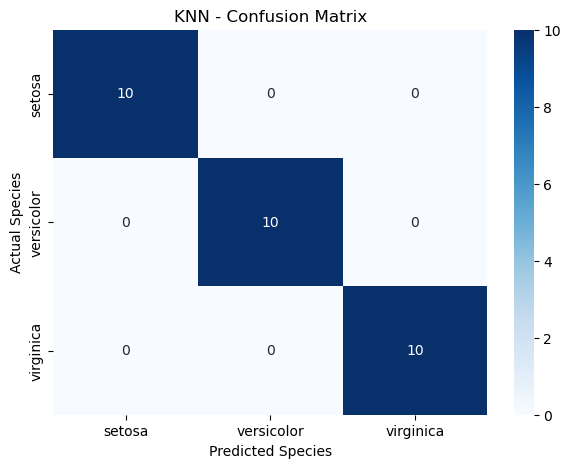

In [39]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("KNN - Confusion Matrix")
plt.xlabel("Predicted Species")
plt.ylabel("Actual Species")

plt.show()

In [40]:
print("KNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Model Comparison

Two classification algorithms were trained and evaluated:

- Logistic Regression
- K-Nearest Neighbors (KNN)

KNN achieved the highest test accuracy of 100%, compared with 96.67% for Logistic Regression.

Therefore, KNN was selected as the best-performing model for this dataset and test split.

In [42]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy": [logistic_accuracy, knn_accuracy]
})

model_comparison["Accuracy (%)"] = model_comparison["Accuracy"] * 100

model_comparison

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.966667,96.666667
1,KNN,1.000000,100.000000


In [43]:
model_comparison["Accuracy (%)"] = model_comparison["Accuracy (%)"].round(2)

model_comparison

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.966667,96.67
1,KNN,1.000000,100.00


## Best Performing Model

Based on the test-set results, K-Nearest Neighbors (KNN) achieved the highest accuracy of 100%, while Logistic Regression achieved 96.67%.

Therefore, KNN was selected as the best-performing model for the Iris Flower Classification task.

In [45]:
best_model = knn_model

print("Best Model: K-Nearest Neighbors (KNN)")
print(f"Test Accuracy: {knn_accuracy * 100:.2f}%")

Best Model: K-Nearest Neighbors (KNN)
Test Accuracy: 100.00%


In [46]:
new_flower = [[5.1, 3.5, 1.4, 0.2]]

prediction = best_model.predict(new_flower)

print("Predicted Species:", prediction[0])

Predicted Species: setosa


C:\Users\Sampurna Patnaik\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


## Conclusion

The Iris Flower Classification project successfully classified iris flowers into
three species: Setosa, Versicolor, and Virginica.

During exploratory data analysis, petal length and petal width were found to be
the most discriminative features, while sepal width showed comparatively more
overlap between species.

Two machine learning classification algorithms were trained and evaluated:

- Logistic Regression achieved 96.67% test accuracy.
- K-Nearest Neighbors (KNN) achieved 100.00% test accuracy.

Based on the results obtained on the selected test set, KNN was selected as the
best-performing model.

The trained KNN model was also used to classify a new flower with measurements
[5.1, 3.5, 1.4, 0.2], and it predicted the species as Setosa.

## Final Results Summary

| Model | Test Accuracy |
|---|---:|
| Logistic Regression | 96.67% |
| K-Nearest Neighbors (KNN) | 100.00% |

### Best Model
K-Nearest Neighbors (KNN) achieved the highest test accuracy of 100.00%
on the selected test set and was therefore selected as the best-performing
model for this project.